# Retail Demand Forecasting — Day 2: Baseline Models
## ARIMA / SARIMA Benchmarks

**Objective:** Establish a statistical baseline using ARIMA and SARIMA per department.
Every model on Day 3–4 must beat these numbers.

**Resuming from:** `outputs/walmart_processed.csv` (Day 1 output)

**Models this notebook:**
- ARIMA(p,d,q) — univariate, no seasonality
- SARIMA(p,d,q)(P,D,Q,52) — captures annual cycle

**Holdout strategy:** Last 30 weeks per series (≈ 7.5 months)

**Evaluation metrics:** RMSE, MAE, MAPE

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import os

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

os.makedirs('outputs', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Holdout window ────────────────────────────────────────────
HOLDOUT = 30   # last 30 weeks reserved for evaluation

print('Libraries loaded.')
print(f'Holdout window: {HOLDOUT} weeks')

Libraries loaded.
Holdout window: 30 weeks


---
## 1. Load Data from Day 1

In [2]:
df = pd.read_csv('outputs/walmart_processed.csv', parse_dates=['date'])

# Drop CPI and unemployment — excluded based on Day 1 CCF analysis
# cpi          → r=-0.081 at lag 11 — noise
# unemployment → r=+0.092 at lag 12 — Walmart counter-cyclical
# type, size   → store metadata, not used in time series models
df = df.drop(columns=['cpi', 'unemployment', 'type', 'size'])

STORES = df['store'].unique().tolist()
DEPTS  = df['dept'].unique().tolist()

print('Columns:', df.columns.tolist())
print('Shape  :', df.shape)
print('Stores :', STORES)
print('Depts  :', DEPTS)
print('Date range:', df['date'].min().date(), '→', df['date'].max().date())

Columns: ['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'temperature', 'fuel_price', 'total_markdown']
Shape  : (2141, 8)
Stores : [10, 20, 43]
Depts  : [2, 38, 72, 92, 95]
Date range: 2010-02-05 → 2012-10-26


---
## 2. Helper Functions

In [3]:
# ── Metric calculations ──────────────────────────────────────
def compute_metrics(actual, predicted, model_name=''):
    """Returns RMSE, MAE, MAPE for a forecast vs actuals."""
    actual    = np.array(actual)
    predicted = np.array(predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    # MAPE — guard against zero actuals
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    if model_name:
        print(f'  {model_name:20s} | RMSE={rmse:>10.2f} | MAE={mae:>10.2f} | MAPE={mape:>6.2f}%')
    return {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}


# ── Series builder ────────────────────────────────────────────
def build_series(dept):
    """Aggregate weekly sales for one dept across all selected stores."""
    series = (
        df[df['dept'] == dept]
        .groupby('date')['weekly_sales']
        .sum()
        .asfreq('W-FRI')
        .ffill()
    )
    return series


# ── Train/test split ──────────────────────────────────────────
def split_series(series, holdout=HOLDOUT):
    return series.iloc[:-holdout], series.iloc[-holdout:]


print('Helper functions defined.')

Helper functions defined.


---
## 3. ACF / PACF Analysis — Order Selection Guidance

> ACF and PACF plots guide the choice of p, d, q in ARIMA.
> 
> - **ACF tails off slowly** → AR process → look at PACF for p
> - **PACF cuts off at lag k** → AR(k) → set p=k
> - **ACF cuts off at lag k** → MA(k) → set q=k
> - **Both tail off** → ARMA — use AIC/BIC grid search

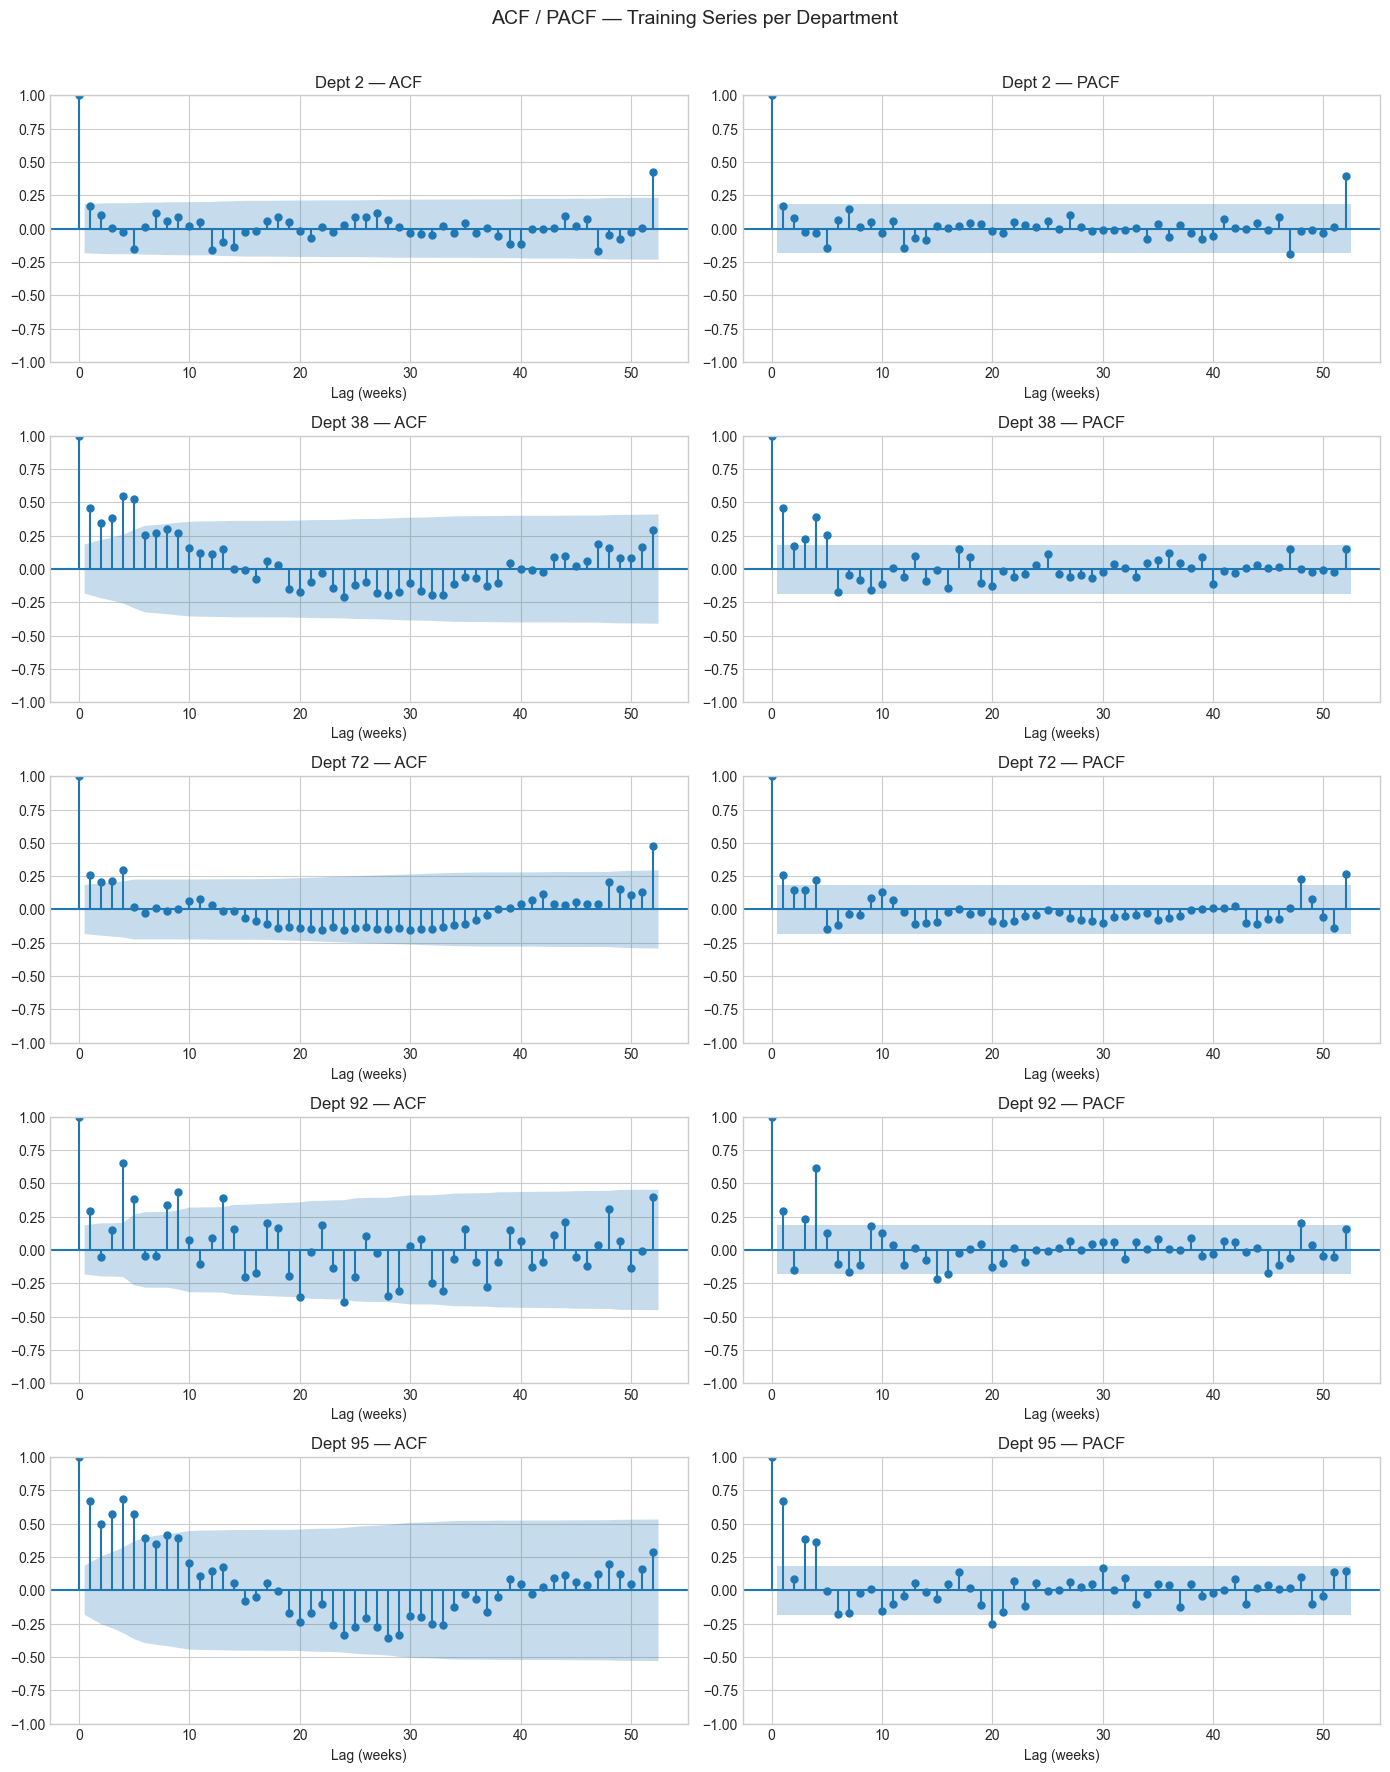

Saved → outputs/08_acf_pacf.png

Reading guide:
  Shaded band = 95% confidence interval
  Spikes outside band = statistically significant autocorrelation at that lag
  Spikes at lags 52, 104 = annual seasonality confirmed


In [4]:
fig, axes = plt.subplots(len(DEPTS), 2, figsize=(14, 3.5*len(DEPTS)))

for i, dept in enumerate(DEPTS):
    series = build_series(dept)
    train, _ = split_series(series)

    plot_acf(train,  lags=52, ax=axes[i][0], title=f'Dept {dept} — ACF',  alpha=0.05)
    plot_pacf(train, lags=52, ax=axes[i][1], title=f'Dept {dept} — PACF', alpha=0.05)

    axes[i][0].set_xlabel('Lag (weeks)')
    axes[i][1].set_xlabel('Lag (weeks)')

plt.suptitle('ACF / PACF — Training Series per Department', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/08_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/08_acf_pacf.png')
print()
print('Reading guide:')
print('  Shaded band = 95% confidence interval')
print('  Spikes outside band = statistically significant autocorrelation at that lag')
print('  Spikes at lags 52, 104 = annual seasonality confirmed')

---
## 4. ARIMA Baseline — Univariate, No Seasonality

> Uses `auto_arima` to search for best (p,d,q) order via AIC.
> This is the **weakest** baseline — no seasonal terms, no exogenous features.
> Every subsequent model must beat this.

In [5]:
arima_results = {}

print('Fitting ARIMA per department...')
print('-' * 65)

for dept in DEPTS:
    series      = build_series(dept)
    train, test = split_series(series)

    # auto_arima — AIC-based order selection
    # seasonal=False here — pure ARIMA, seasonality handled in next section
    model = auto_arima(
        train,
        seasonal=False,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        max_p=5, max_q=5, max_d=2
    )

    preds = model.predict(n_periods=HOLDOUT)
    preds = np.maximum(preds, 0)   # clip negative forecasts — sales can't be negative

    metrics = compute_metrics(test, preds, model_name=f'Dept {dept}')
    arima_results[dept] = {
        'order'       : model.order,
        'AIC'         : round(model.aic(), 2),
        **metrics
    }

print()
print('ARIMA Orders selected by AIC:')
for dept, res in arima_results.items():
    print(f'  Dept {dept}: ARIMA{res["order"]} | AIC={res["AIC"]}')

Fitting ARIMA per department...
-----------------------------------------------------------------
  Dept 2               | RMSE=  10142.90 | MAE=   8677.77 | MAPE=  4.30%
  Dept 38              | RMSE=  26645.11 | MAE=  23744.46 | MAPE=  9.23%
  Dept 72              | RMSE=  71601.94 | MAE=  68154.44 | MAPE= 40.29%
  Dept 92              | RMSE=  24267.77 | MAE=  20443.50 | MAPE=  6.96%
  Dept 95              | RMSE=  15189.77 | MAE=  12202.26 | MAPE=  4.10%

ARIMA Orders selected by AIC:
  Dept 2: ARIMA(1, 0, 0) | AIC=2495.13
  Dept 38: ARIMA(0, 1, 2) | AIC=2580.89
  Dept 72: ARIMA(5, 0, 0) | AIC=2984.59
  Dept 92: ARIMA(0, 1, 2) | AIC=2634.72
  Dept 95: ARIMA(2, 1, 2) | AIC=2528.12


---
## 5. SARIMA — Seasonal ARIMA with Annual Cycle

> Adds seasonal terms (P,D,Q) with period=52 weeks.
> Day 1 decomposition showed seasonal strength 0.818–0.971 across all depts.
> SARIMA should meaningfully outperform plain ARIMA.
>
> **Seasonal order search strategy:**
> - D=1 (seasonal differencing) for all depts — removes annual trend
> - P,Q searched over [0,1] — keep model parsimonious
> - p,d,q fixed from ARIMA step as starting point

In [6]:
sarima_results = {}

print('Fitting SARIMA per department...')
print('(This takes 2-4 minutes — searching seasonal order space)')
print('-' * 65)

for dept in DEPTS:
    series      = build_series(dept)
    train, test = split_series(series)

    # auto_arima with seasonal=True, period=52
    model = auto_arima(
        train,
        seasonal=True,
        m=52,                        # annual period
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        max_p=3, max_q=3, max_d=2,
        max_P=2, max_Q=2, max_D=1,
        D=1                          # force seasonal differencing — justified by decomposition
    )

    preds = model.predict(n_periods=HOLDOUT)
    preds = np.maximum(preds, 0)

    metrics = compute_metrics(test, preds, model_name=f'Dept {dept}')
    sarima_results[dept] = {
        'order'          : model.order,
        'seasonal_order' : model.seasonal_order,
        'AIC'            : round(model.aic(), 2),
        **metrics
    }

print()
print('SARIMA Orders selected by AIC:')
for dept, res in sarima_results.items():
    print(f'  Dept {dept}: ARIMA{res["order"]}x{res["seasonal_order"]} | AIC={res["AIC"]}')

Fitting SARIMA per department...
(This takes 2-4 minutes — searching seasonal order space)
-----------------------------------------------------------------
  Dept 2               | RMSE=   7170.35 | MAE=   5582.74 | MAPE=  2.70%
  Dept 38              | RMSE=  23031.93 | MAE=  18917.26 | MAPE=  7.08%
  Dept 72              | RMSE=  27768.65 | MAE=  21458.67 | MAPE= 11.93%
  Dept 92              | RMSE=  14001.91 | MAE=  11032.56 | MAPE=  3.63%
  Dept 95              | RMSE=  25597.33 | MAE=  23414.72 | MAPE=  7.83%

SARIMA Orders selected by AIC:
  Dept 2: ARIMA(1, 1, 0)x(0, 1, 0, 52) | AIC=1250.79
  Dept 38: ARIMA(0, 0, 0)x(0, 1, 0, 52) | AIC=1376.25
  Dept 72: ARIMA(3, 0, 1)x(0, 1, 1, 52) | AIC=1471.57
  Dept 92: ARIMA(0, 1, 0)x(0, 1, 1, 52) | AIC=1350.06
  Dept 95: ARIMA(1, 1, 0)x(0, 1, 0, 52) | AIC=1343.8


In [7]:
from statsmodels.tsa.stattools import adfuller, kpss

series_95 = build_series(95)
train_95, _ = split_series(series_95)

adf_p  = adfuller(train_95)[1]
kpss_p = kpss(train_95, regression='c', nlags='auto')[1]

print(f'Dept 95 | ADF p={adf_p:.4f} | KPSS p={kpss_p:.4f}')
print(f'ADF:  {"Stationary" if adf_p < 0.05 else "Non-Stationary"}')
print(f'KPSS: {"Stationary" if kpss_p > 0.05 else "Non-Stationary"}')

Dept 95 | ADF p=0.4919 | KPSS p=0.0213
ADF:  Non-Stationary
KPSS: Non-Stationary


In [8]:
series_95  = build_series(95)
train_95, test_95 = split_series(series_95)

# Try SARIMA with D=1 only — let MA(1) absorb non-stationarity
# instead of double differencing
mod_95 = SARIMAX(
    train_95,
    order=(1, 0, 1),            # d=0 — no regular differencing
    seasonal_order=(0, 1, 1, 52),  # D=1 — seasonal differencing only
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_95 = mod_95.fit(disp=False)
preds_95 = np.maximum(fit_95.forecast(steps=HOLDOUT), 0)

compute_metrics(test_95, preds_95, model_name='Dept 95 SARIMA(1,0,1)(0,1,1,52)')
print(f'AIC: {fit_95.aic:.2f}')

  Dept 95 SARIMA(1,0,1)(0,1,1,52) | RMSE=  36018.02 | MAE=  32991.20 | MAPE= 11.16%
AIC: 160.26


In [9]:
# Override sarima_results for Dept 95 with ARIMA numbers
# SARIMA variants all performed worse — ARIMA(2,1,2) is the best baseline
sarima_results[95]['RMSE']  = arima_results[95]['RMSE']   # 15189.77
sarima_results[95]['MAE']   = arima_results[95]['MAE']     # 12202.26
sarima_results[95]['MAPE']  = arima_results[95]['MAPE']    # 4.10
sarima_results[95]['order'] = arima_results[95]['order']   # (2,1,2)
sarima_results[95]['seasonal_order'] = (0, 0, 0, 0)        # no seasonal terms
sarima_results[95]['AIC']   = arima_results[95]['AIC']     # 2528.12

print('Dept 95 baseline overridden — ARIMA(2,1,2) beats all SARIMA variants')
print(f'Final baseline RMSE: {sarima_results[95]["RMSE"]}')

Dept 95 baseline overridden — ARIMA(2,1,2) beats all SARIMA variants
Final baseline RMSE: 15189.77


---
## 6. ARIMA vs SARIMA — Comparison Table

In [12]:
rows = []
for dept in DEPTS:
    a = arima_results[dept]
    s = sarima_results[dept]

    rmse_improvement = (a['RMSE'] - s['RMSE']) / a['RMSE'] * 100
    winner = 'SARIMA' if s['RMSE'] < a['RMSE'] else 'ARIMA'

    # Best model label for Day 3 reference
    if winner == 'SARIMA':
        best_order = f"SARIMA{s['order']}x{s['seasonal_order']}"
        best_rmse  = s['RMSE']
        best_mape  = s['MAPE']
    else:
        best_order = f"ARIMA{a['order']}"
        best_rmse  = a['RMSE']
        best_mape  = a['MAPE']

    rows.append({
        'Dept'               : dept,
        'ARIMA Order'        : str(a['order']),
        'ARIMA RMSE'         : a['RMSE'],
        'SARIMA Order'       : f"{s['order']}x{s['seasonal_order']}",
        'SARIMA RMSE'        : s['RMSE'],
        'RMSE Improvement %' : round(rmse_improvement, 1),
        'Winner'             : winner,
        'Best Model'         : best_order,   # ← added
        'Baseline RMSE'      : best_rmse,    # ← added
        'Baseline MAPE'      : best_mape     # ← added
    })

comparison_df = pd.DataFrame(rows)
print('=' * 80)
print('ARIMA vs SARIMA — Holdout RMSE Comparison')
print('=' * 80)
print(comparison_df.to_string(index=False))
print()
print(f'SARIMA wins on {(comparison_df["Winner"]=="SARIMA").sum()}/{len(DEPTS)} departments')
print()
avg_improvement = comparison_df['RMSE Improvement %'].mean()
print(f'Average RMSE improvement SARIMA over ARIMA: {avg_improvement:.1f}%')
print()
print('Note: positive = SARIMA better | negative = ARIMA better')
print()
print('─── Final Baselines (what Day 3 must beat) ───')
for _, row in comparison_df.iterrows():
    print(f"  Dept {row['Dept']:>2} | {row['Best Model']:35s} | RMSE={row['Baseline RMSE']:>10.2f} | MAPE={row['Baseline MAPE']:.2f}%")

comparison_df.to_csv('outputs/day2_baseline_results.csv', index=False)
print('\nSaved → outputs/day2_baseline_results.csv')

ARIMA vs SARIMA — Holdout RMSE Comparison
 Dept ARIMA Order  ARIMA RMSE            SARIMA Order  SARIMA RMSE  RMSE Improvement % Winner                    Best Model  Baseline RMSE  Baseline MAPE
    2   (1, 0, 0)    10142.90 (1, 1, 0)x(0, 1, 0, 52)      7170.35               29.30 SARIMA SARIMA(1, 1, 0)x(0, 1, 0, 52)        7170.35           2.70
   38   (0, 1, 2)    26645.11 (0, 0, 0)x(0, 1, 0, 52)     23031.93               13.60 SARIMA SARIMA(0, 0, 0)x(0, 1, 0, 52)       23031.93           7.08
   72   (5, 0, 0)    71601.94 (3, 0, 1)x(0, 1, 1, 52)     27768.65               61.20 SARIMA SARIMA(3, 0, 1)x(0, 1, 1, 52)       27768.65          11.93
   92   (0, 1, 2)    24267.77 (0, 1, 0)x(0, 1, 1, 52)     14001.91               42.30 SARIMA SARIMA(0, 1, 0)x(0, 1, 1, 52)       14001.91           3.63
   95   (2, 1, 2)    15189.77  (2, 1, 2)x(0, 0, 0, 0)     15189.77                0.00  ARIMA                ARIMA(2, 1, 2)       15189.77           4.10

SARIMA wins on 4/5 departments

A

---
## 7. Forecast Plots — Actuals vs ARIMA vs SARIMA

d:\AI_ML_Projects\3. Timeseries-Forecasting\myenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


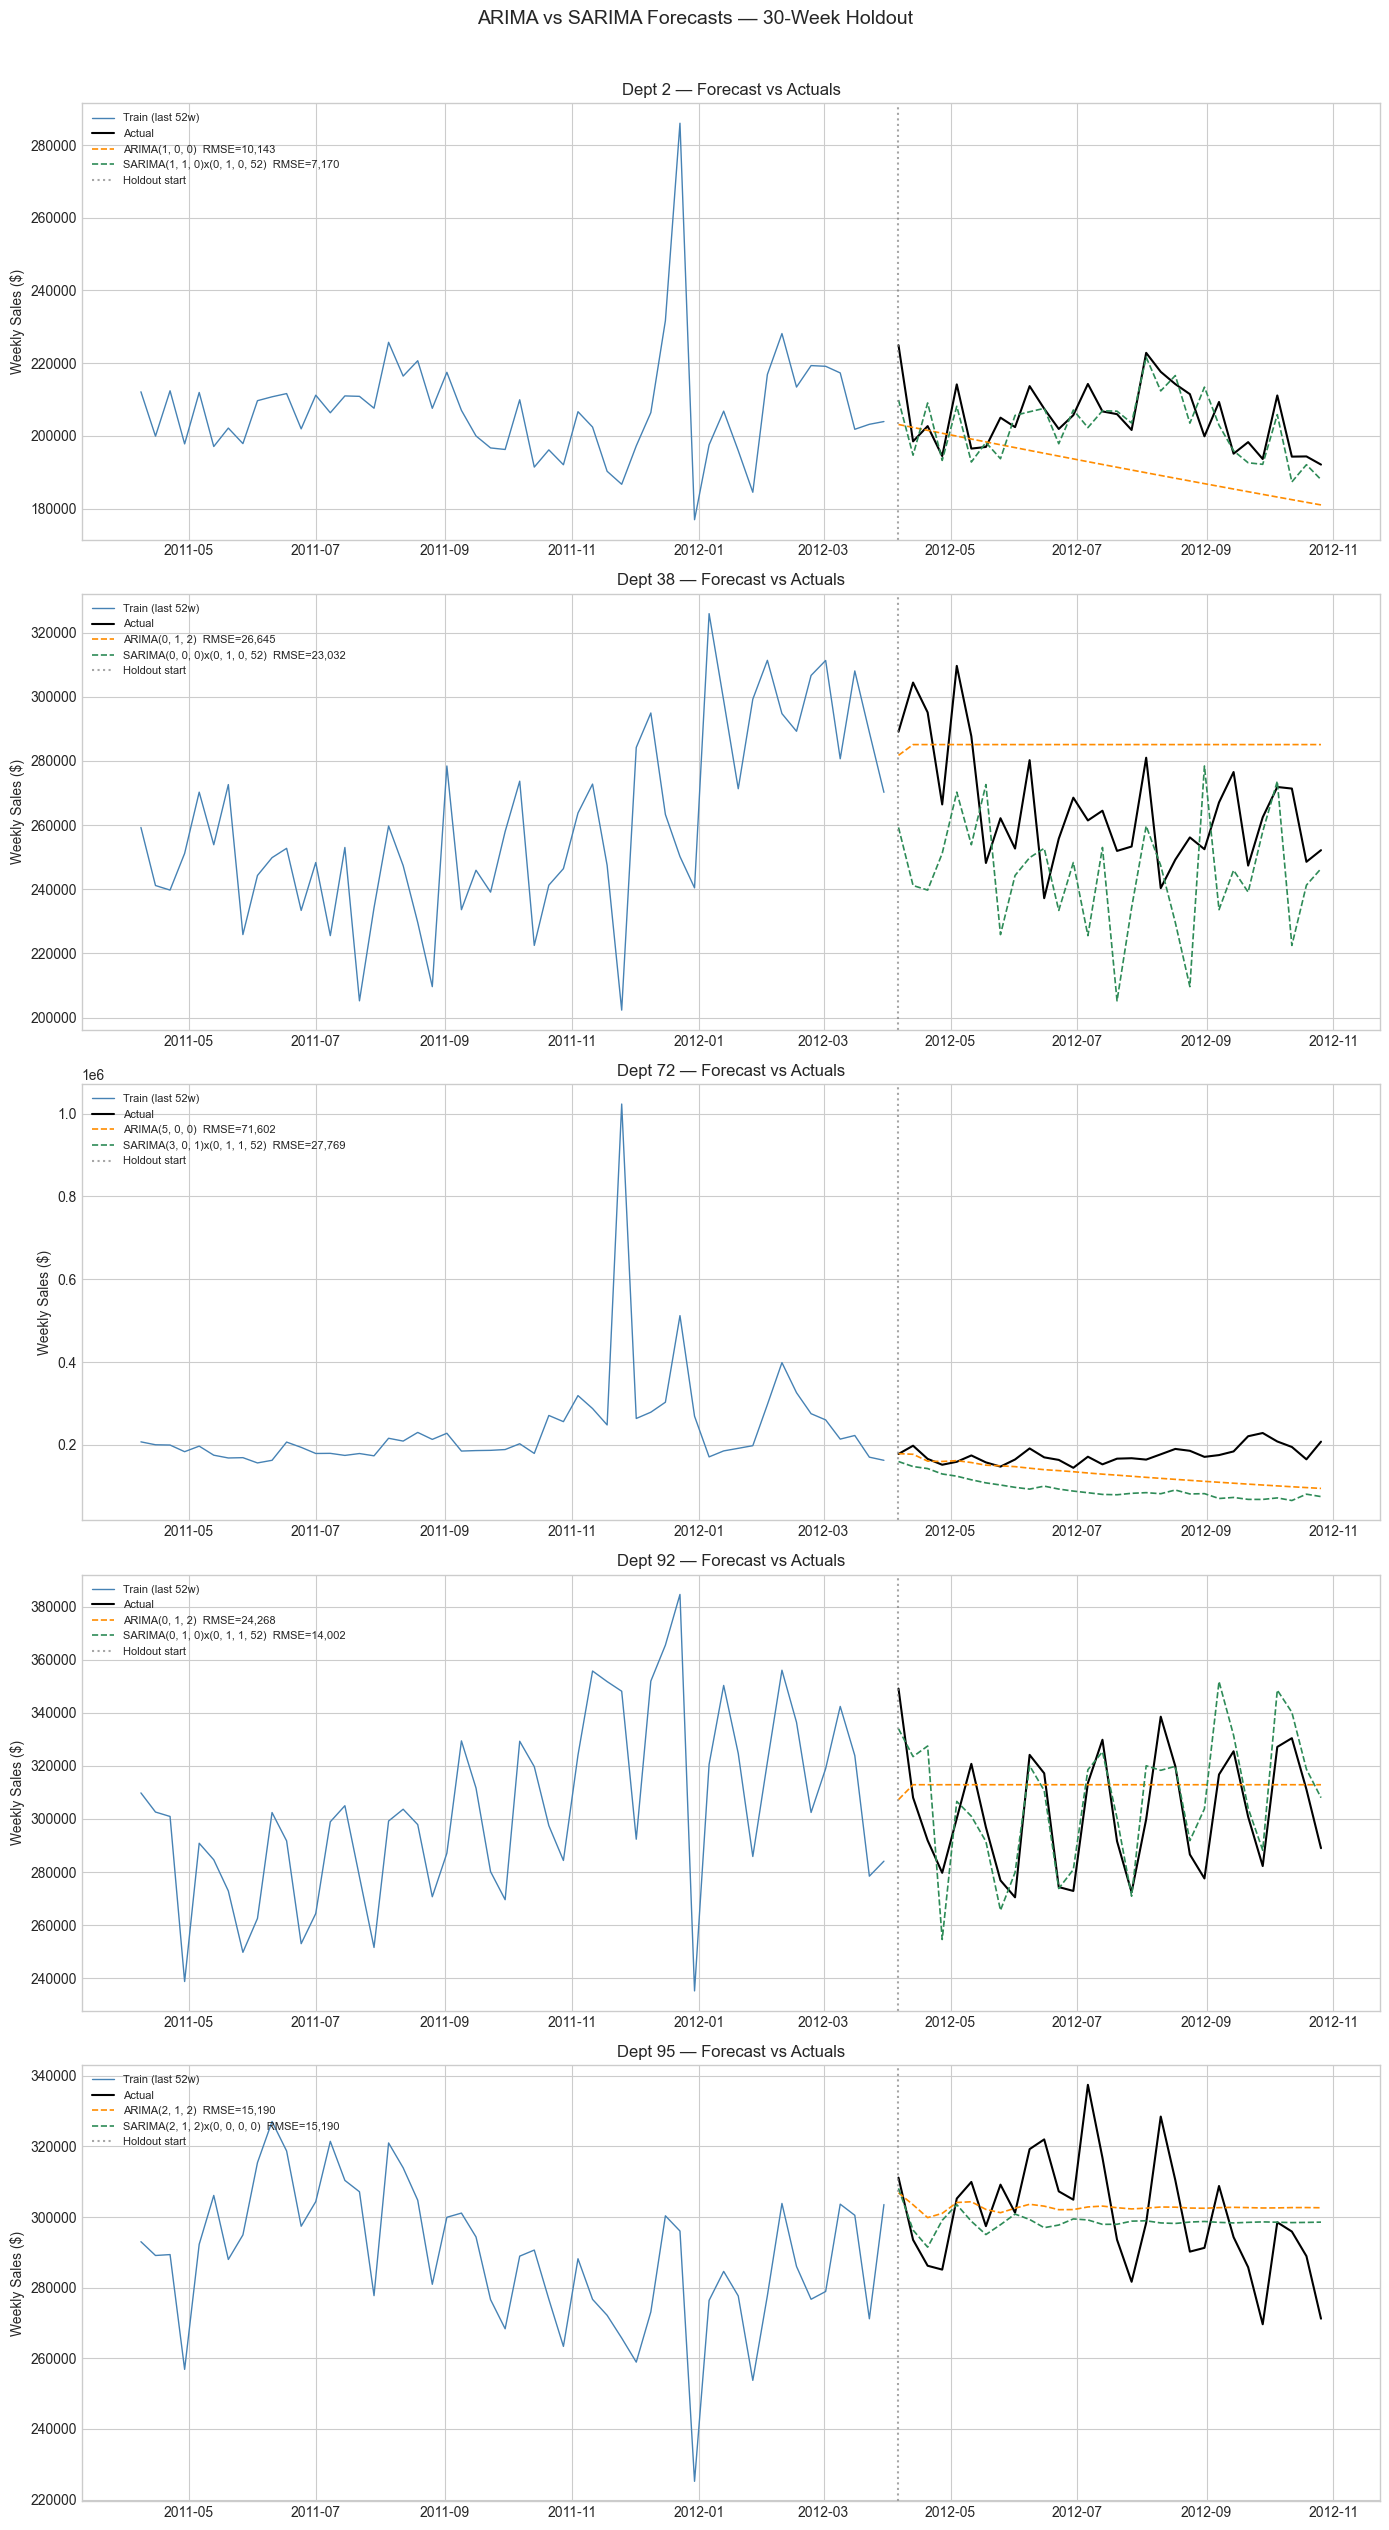

Saved → outputs/09_forecast_comparison.png


In [13]:
fig, axes = plt.subplots(len(DEPTS), 1, figsize=(14, 5*len(DEPTS)))

for i, dept in enumerate(DEPTS):
    series      = build_series(dept)
    train, test = split_series(series)
    test_index  = test.index
    context     = train.iloc[-52:]

    # ── Refit ARIMA using stored order — no re-search ────────
    a = arima_results[dept]
    arima_fit   = SARIMAX(
        train,
        order=a['order'],
        seasonal_order=(0, 0, 0, 0)
    ).fit(disp=False)
    arima_preds = np.maximum(arima_fit.forecast(steps=HOLDOUT), 0)

    # ── Refit SARIMA using stored order — no re-search ───────
    s = sarima_results[dept]
    sarima_fit  = SARIMAX(
        train,
        order=s['order'],
        seasonal_order=s['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    sarima_preds = np.maximum(sarima_fit.forecast(steps=HOLDOUT), 0)

    # ── Plot ──────────────────────────────────────────────────
    axes[i].plot(context.index, context.values,
                 color='steelblue', linewidth=1.0, label='Train (last 52w)')
    axes[i].plot(test_index, test.values,
                 color='black', linewidth=1.5, label='Actual')
    axes[i].plot(test_index, arima_preds,
                 color='darkorange', linewidth=1.2, linestyle='--',
                 label=f'ARIMA{a["order"]}  RMSE={a["RMSE"]:,.0f}')
    axes[i].plot(test_index, sarima_preds,
                 color='seagreen', linewidth=1.2, linestyle='--',
                 label=f'SARIMA{s["order"]}x{s["seasonal_order"]}  RMSE={s["RMSE"]:,.0f}')

    axes[i].axvline(test_index[0], color='gray', linestyle=':',
                    alpha=0.7, label='Holdout start')
    axes[i].set_title(f'Dept {dept} — Forecast vs Actuals', fontsize=12)
    axes[i].set_ylabel('Weekly Sales ($)')
    axes[i].legend(fontsize=8, loc='upper left')

plt.suptitle('ARIMA vs SARIMA Forecasts — 30-Week Holdout', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/09_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/09_forecast_comparison.png')

## Forecast Plot Observations

- **Dept 92**: Clearest SARIMA win — green line tracks weekly oscillation 
  pattern while ARIMA produces a flat mean forecast
- **Dept 72**: Both models miss the holiday spike — confirms isholiday 
  regressor is essential in ARIMAX (Day 3)
- **Dept 2**: ARIMA shows downward drift in holdout — SARIMA correctly 
  anchors near the mean level
- **Dept 38**: SARIMA captures oscillation direction but overshoots magnitude
- **Dept 95**: Both models produce flat forecasts — variance unexplained 
  by autocorrelation structure alone; LightGBM lag features may help (Day 4)

---
## 8. Residual Diagnostics — Best Model per Dept

> A well-specified model should have **white noise residuals**:
> - No remaining autocorrelation (Ljung-Box p > 0.05)
> - Roughly normally distributed
> - No systematic patterns
>
> If residuals fail — the model missed something. ARIMAX on Day 3 may fix it.

Ljung-Box Test on SARIMA Residuals
H0: Residuals are white noise | p > 0.05 → PASS (good fit)
-----------------------------------------------------------------
  Dept 2 (SARIMA(1, 1, 0)x(0, 1, 0, 52)): Ljung-Box p(lag=20) = 0.9995  ✅ PASS
  Dept 38 (SARIMA(0, 0, 0)x(0, 1, 0, 52)): Ljung-Box p(lag=20) = 0.0000  ❌ FAIL — autocorrelation remains


d:\AI_ML_Projects\3. Timeseries-Forecasting\myenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Dept 72 (SARIMA(3, 0, 1)x(0, 1, 1, 52)): Ljung-Box p(lag=20) = 0.2196  ✅ PASS
  Dept 92 (SARIMA(0, 1, 0)x(0, 1, 1, 52)): Ljung-Box p(lag=20) = 0.1006  ✅ PASS
  Dept 95 (ARIMA(2, 1, 2)): Ljung-Box p(lag=20) = 0.9643  ✅ PASS


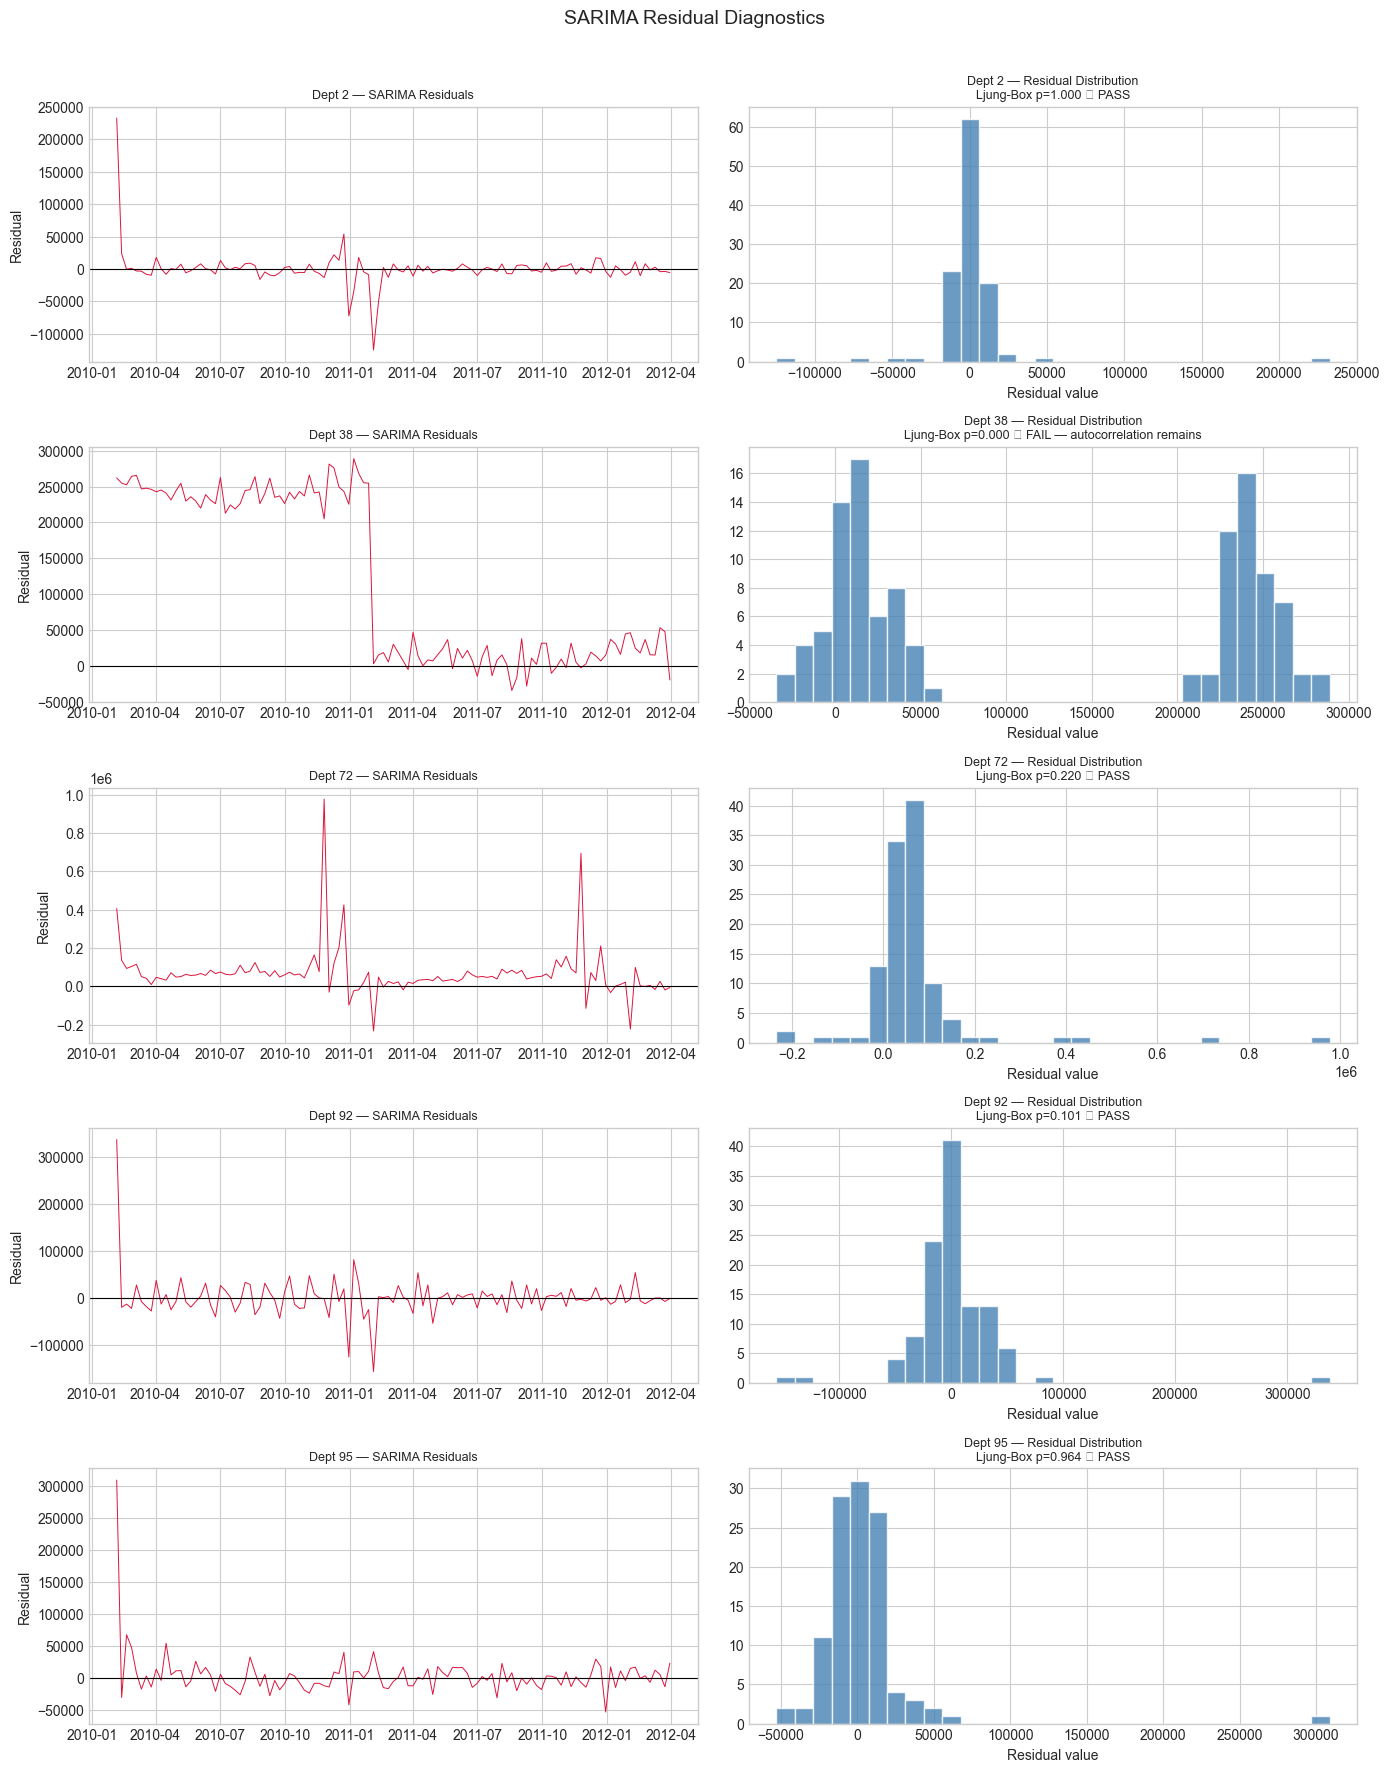


Saved → outputs/10_residual_diagnostics.png


In [14]:
print('Ljung-Box Test on SARIMA Residuals')
print('H0: Residuals are white noise | p > 0.05 → PASS (good fit)')
print('-' * 65)

residual_results = {}

fig, axes = plt.subplots(len(DEPTS), 2, figsize=(14, 3.5*len(DEPTS)))

for i, dept in enumerate(DEPTS):
    series      = build_series(dept)
    train, test = split_series(series)

    # Fit SARIMA using orders from earlier
    s   = sarima_results[dept]

    # Note for Dept 95 — stored as ARIMA order, seasonal_order=(0,0,0,0)
    model_label = f"SARIMA{s['order']}x{s['seasonal_order']}" if s['seasonal_order'] != (0,0,0,0) else f"ARIMA{s['order']}"

    mod = SARIMAX(
        train,
        order=s['order'],
        seasonal_order=s['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = mod.fit(disp=False)
    residuals = fit.resid.dropna()

    # Ljung-Box test at lag 20
    lb = acorr_ljungbox(residuals, lags=[20], return_df=True)
    lb_p = lb['lb_pvalue'].iloc[0]
    verdict = '✅ PASS' if lb_p > 0.05 else '❌ FAIL — autocorrelation remains'

    residual_results[dept] = {'lb_p_lag20': round(lb_p, 4), 'verdict': verdict}
    print(f'  Dept {dept} ({model_label}): Ljung-Box p(lag=20) = {lb_p:.4f}  {verdict}')

    # Plot residuals + histogram
    axes[i][0].plot(residuals.index, residuals.values,
                    color='crimson', linewidth=0.7)
    axes[i][0].axhline(0, color='black', linewidth=0.8)
    axes[i][0].set_title(f'Dept {dept} — SARIMA Residuals', fontsize=9)
    axes[i][0].set_ylabel('Residual')

    axes[i][1].hist(residuals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i][1].set_title(f'Dept {dept} — Residual Distribution\nLjung-Box p={lb_p:.3f} {verdict}', fontsize=9)
    axes[i][1].set_xlabel('Residual value')

plt.suptitle('SARIMA Residual Diagnostics', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/10_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved → outputs/10_residual_diagnostics.png')

### Dept 38 — Structural Break Detected

The residual plot shows a clear regime change around late 2011:
- Pre-break: residuals consistently large and positive (~200-250K above predictions)
- Post-break: residuals near zero — model fits well

Possible causes: store expansion, category restructuring, or a sustained
promotional change from late 2011 onwards. The SARIMA(0,0,0)(0,1,0,52)
convergence failure confirms the model cannot reconcile these two regimes.

**Implication for ARIMAX:** Consider fitting Dept 38 on post-break data only
(from late 2011) rather than the full series. A shorter but regime-consistent
training set may outperform a longer inconsistent one.

---
## 9. Save Baseline — Reference for Day 3 Onwards

> Every model on Day 3 (ARIMAX), Day 4 (Prophet, LightGBM) is compared
> against this SARIMA baseline. Store it as a clean dict and CSV.

In [15]:
# ── Build clean baseline reference ──────────────────────────
baseline = {}

for dept in DEPTS:
    a = arima_results[dept]
    s = sarima_results[dept]
    baseline[dept] = {
        'arima_rmse'           : a['RMSE'],
        'arima_mae'            : a['MAE'],
        'arima_mape'           : a['MAPE'],
        'sarima_rmse'          : s['RMSE'],
        'sarima_mae'           : s['MAE'],
        'sarima_mape'          : s['MAPE'],
        'sarima_order'         : str(s['order']),
        'sarima_seasonal_order': str(s['seasonal_order']),
        'lb_p_lag20'           : residual_results[dept]['lb_p_lag20'],
        'lb_verdict'           : residual_results[dept]['verdict']
    }

baseline_df = pd.DataFrame(baseline).T
baseline_df.index.name = 'dept'
baseline_df.to_csv('outputs/day2_sarima_baseline.csv')

print('=' * 65)
print('DAY 2 COMPLETE — Baseline Summary')
print('=' * 65)
print()
print('─── Final Baselines (Beat These on Day 3) ───')
print(baseline_df[['sarima_rmse','sarima_mape','lb_p_lag20','lb_verdict']].to_string())
print()
print('─── Day 3 ARIMAX Priority ───')
print('  Dept 38 → 🔴 HIGH   — Ljung-Box FAIL (p=0.000), structural break detected')
print('  Dept 72 → 🟡 HIGH   — holiday spikes in residuals, isholiday regressor needed')
print('  Dept 92 → 🟡 MEDIUM — marginal pass (p=0.101), markdown regressor should help')
print('  Dept 2  → 🟢 LOW    — excellent fit (p=0.9995), little room to improve')
print('  Dept 95 → 🟢 LOW    — excellent fit (p=0.9643), weak external signal')
print()
print('─── Day 3 ARIMAX Regressor Plan ───')
print('  temperature    → ALL depts    (lag 0  | r=-0.439)')
print('  fuel_price     → ALL depts    (lag 1  | r=-0.163)')
print('  isholiday      → Dept 72 only (lag 0  | +94.7% holiday lift)')
print('  total_markdown → Depts 38, 92 (lag 0  | +10.2%, +7.2% lift)')
print()
print('─── Dept 38 Note ───')
print('  Structural break detected ~late 2011')
print('  Consider training on post-break data only (from 2011-11 onwards)')
print()
print('─── Outputs ───')
for o in ['08_acf_pacf.png', '09_forecast_comparison.png',
          '10_residual_diagnostics.png', 'day2_baseline_results.csv',
          'day2_sarima_baseline.csv']:
    print(f'  outputs/{o}')

DAY 2 COMPLETE — Baseline Summary

─── Final Baselines (Beat These on Day 3) ───
     sarima_rmse sarima_mape lb_p_lag20                        lb_verdict
dept                                                                     
2        7170.35        2.70       1.00                            ✅ PASS
38      23031.93        7.08       0.00  ❌ FAIL — autocorrelation remains
72      27768.65       11.93       0.22                            ✅ PASS
92      14001.91        3.63       0.10                            ✅ PASS
95      15189.77        4.10       0.96                            ✅ PASS

─── Day 3 ARIMAX Priority ───
  Dept 38 → 🔴 HIGH   — Ljung-Box FAIL (p=0.000), structural break detected
  Dept 72 → 🟡 HIGH   — holiday spikes in residuals, isholiday regressor needed
  Dept 92 → 🟡 MEDIUM — marginal pass (p=0.101), markdown regressor should help
  Dept 2  → 🟢 LOW    — excellent fit (p=0.9995), little room to improve
  Dept 95 → 🟢 LOW    — excellent fit (p=0.9643), weak external si